<a href="https://colab.research.google.com/github/aghosh92/Course-Lectures/blob/main/Notebooks/No_Free_Lunch_share.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# No Free Lunch — One Problem, Many Algorithms
### AI for Physical Sciences · Lecture Notebook

**Prepared by: Ayana Ghosh**
Contact: research.aghosh@gmail.com

Acknowledgment: Claude
---

**The No Free Lunch (NFL) theorem** (Wolpert & Macready, 1997):

> *Averaged over all possible datasets, every learning algorithm has the same expected performance — including random guessing.*

The practical consequence: **every algorithm encodes assumptions about the world** (its *inductive bias*). When those assumptions match the structure of the data, the algorithm wins. When they don't, it fails. Choosing an algorithm is choosing which assumptions to make — and domain knowledge is how you make that choice well.

We demonstrate this experimentally using **one synthetic physical dataset**, running six algorithms from simplest to most flexible, examining the mathematics behind each, then proving the NFL theorem by changing the problem and watching the winner change.

---

| Step | Algorithm | Core assumption | Key equation |
|---|---|---|---|
| 1 | Dataset | — | $y = 3x_1 + 2x_2^2 + \sin(4x_3) + \varepsilon$ |
| 2 | Linear regression | $g(x)$ is a hyperplane | $\boldsymbol{\beta}^* = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}$ |
| 3 | Ridge (L2) | Linear + small weights | $\boldsymbol{\beta}^* = (\mathbf{X}^\top\mathbf{X} + \lambda\mathbf{I})^{-1}\mathbf{X}^\top\mathbf{y}$ |
| 4 | LASSO (L1) | Linear + sparse | Soft-threshold: $S_\lambda(z)=\text{sign}(z)\max(|z|-\lambda,0)$ |
| 5 | Kernel Ridge | Smooth in RKHS | $f(x) = \sum_i \alpha_i k(x_i, x)$ |
| 6 | Random Forest | Piecewise constant | $f(x) = \frac{1}{T}\sum_t f_t(x)$ |
| 7 | Neural Network | Learnable hierarchy | $f = W_L\sigma(\cdots\sigma(W_1 x))$ |
| 8 | NFL proof | — | Change the problem → watch the winner change |

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_predict, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'figure.dpi': 110,
})
np.random.seed(42)

# Helper: RMSE (more interpretable than MSE — same units as y)
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print('Libraries loaded.')

Libraries loaded.


---
## Step 1 — The Dataset: A Synthetic Physical Problem

We simulate a measurement campaign on a hypothetical material system. The target property $y$ (think: formation energy, bandgap, conductivity) depends on **three physical features** via a nonlinear function:

$$\boxed{y = 3x_1 + 2x_2^2 + \sin(4x_3) + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, 0.4^2)}$$

**But we don't know this.** We observe the full 20-dimensional vector $[x_1, \ldots, x_{20}]$ where $x_4, \ldots, x_{20}$ are **irrelevant noise descriptors** — a very common situation in materials science.

| Feature | Role | Physical analogy |
|---|---|---|
| $x_1$ | Linear | Electronegativity difference |
| $x_2$ | Quadratic ($x_2^2$) | Atomic radius (scales volume as $r^2$) |
| $x_3$ | Oscillatory ($\sin 4x_3$) | Orbital phase, bond angle |
| $x_4$–$x_{20}$ | Noise | Redundant / irrelevant descriptors |

**Irreducible noise floor:** $\sigma = 0.4$. No model can achieve RMSE < 0.4 on this dataset, regardless of how expressive it is.

Training samples:  350
Test samples:      150
Features:          20  (3 relevant + 17 noise)
Noise level σ:     0.4  →  RMSE lower bound = 0.4


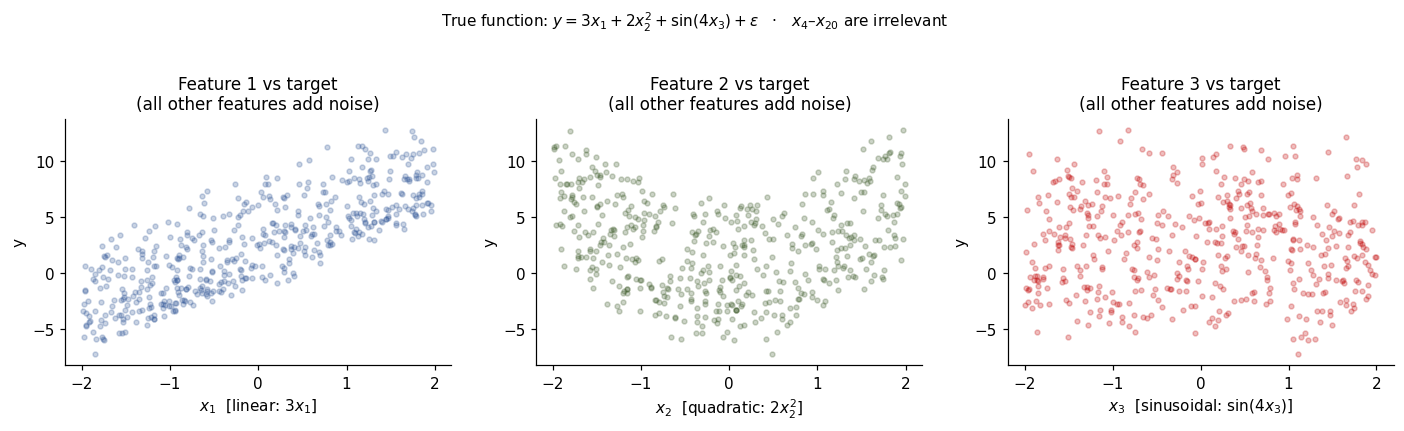

In [ ]:
# ── Generate the dataset ──────────────────────────────────────────────────────
N          = 500
n_features = 20
noise_level = 0.4

X = np.random.uniform(-2, 2, (N, n_features))

def true_function(X):
    """The true underlying function — unknown to the algorithms."""
    return 3*X[:, 0] + 2*(X[:, 1]**2) + np.sin(4*X[:, 2])

y = true_function(X) + noise_level * np.random.randn(N)

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1)

# Scale features — required for linear models, kernel methods, neural nets
# (NOT needed for Random Forest — tree splits are scale-invariant)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit ONLY on train
X_test_s  = scaler.transform(X_test)        # apply same transform to test

print(f'Training samples:  {X_train.shape[0]}')
print(f'Test samples:      {X_test.shape[0]}')
print(f'Features:          {n_features}  (3 relevant + 17 noise)')
print(f'Noise level σ:     {noise_level}  →  RMSE lower bound = {noise_level}')

# ── Visualise the three relevant components ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
components = [
    (0, r'$x_1$  [linear: $3x_1$]',          '#2E5496'),
    (1, r'$x_2$  [quadratic: $2x_2^2$]',      '#375623'),
    (2, r'$x_3$  [sinusoidal: $\sin(4x_3)$]', '#C00000'),
]
for ax, (fi, label, col) in zip(axes, components):
    ax.scatter(X[:, fi], y, alpha=0.25, s=10, color=col)
    ax.set_xlabel(label); ax.set_ylabel('y')
    ax.set_title(f'Feature {fi+1} vs target\n(all other features add noise)')

plt.suptitle(r'True function: $y = 3x_1 + 2x_2^2 + \sin(4x_3) + \varepsilon$   ·   $x_4$–$x_{20}$ are irrelevant',
             y=1.02, fontsize=10)
plt.tight_layout()
plt.show()

---
## Step 2 — Linear Regression

### Mathematics

**Model:** $f(\mathbf{x};\boldsymbol{\beta}) = \boldsymbol{\beta}^\top \mathbf{x} + \beta_0$ — a hyperplane in feature space.

**Loss:** minimise mean squared error:
$$L(\boldsymbol{\beta}) = \frac{1}{N}\|\mathbf{X}\boldsymbol{\beta} - \mathbf{y}\|_2^2$$

**Closed-form solution** — set $\nabla_\beta L = 0$, solve exactly (no iterations needed):
$$\boldsymbol{\beta}^* = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$$

This is the **normal equation**. One matrix inversion, exact solution.

**Inductive bias:** $g(\mathbf{x})$ is exactly linear in the 20 features.

**Expected behaviour here:** our function contains $2x_2^2$ (quadratic) and $\sin(4x_3)$ (periodic) — neither is linear. Linear regression must approximate them with a line. It will underfit these components and spread weight across all 20 features including the 17 noise ones.

Linear Regression
  β* = (XᵀX)⁻¹ Xᵀy  [closed form, zero iterations]
  Test RMSE = 2.5281   R² = 0.6377
  Gap above noise floor: +2.1281



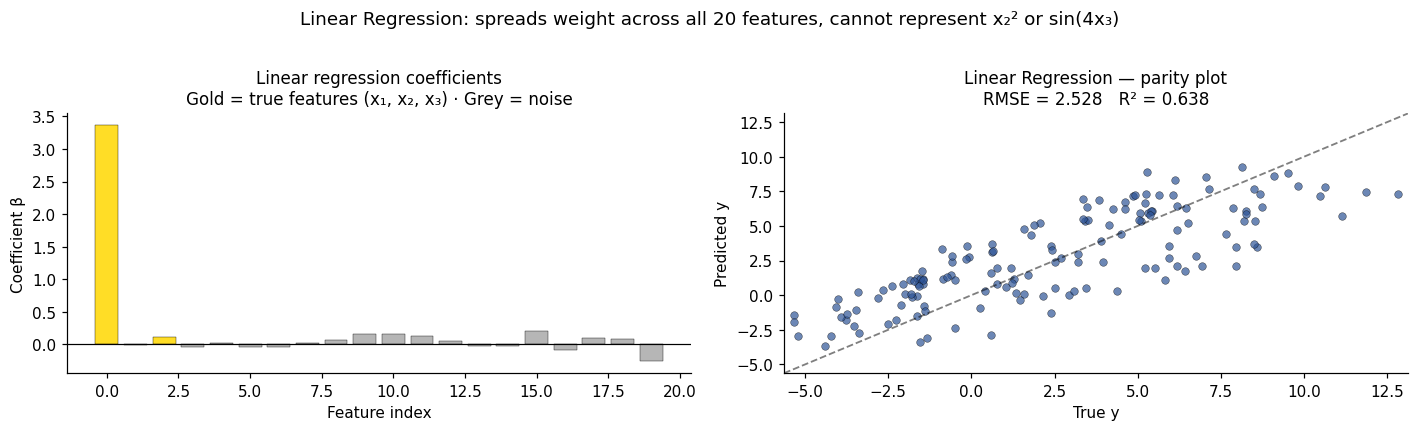

Nonzero coefficients: 20 / 20
All 20 features get nonzero weight — including the 17 irrelevant ones.
The model is forced to use noise as signal.


In [ ]:
# ── Linear Regression ─────────────────────────────────────────────────────────
lin = LinearRegression()
lin.fit(X_train_s, y_train)
pred_lin = lin.predict(X_test_s)

rmse_lin = rmse(y_test, pred_lin)
r2_lin   = r2_score(y_test, pred_lin)

print('Linear Regression')
print(f'  β* = (XᵀX)⁻¹ Xᵀy  [closed form, zero iterations]')
print(f'  Test RMSE = {rmse_lin:.4f}   R² = {r2_lin:.4f}')
print(f'  Gap above noise floor: +{rmse_lin - noise_level:.4f}')
print()

# Show learned coefficients — does it put weight on the right features?
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))

colors_coef = ['#FFD700' if i < 3 else '#AAAAAA' for i in range(n_features)]
axes[0].bar(range(n_features), lin.coef_, color=colors_coef, edgecolor='k', lw=0.3, alpha=0.85)
axes[0].axhline(0, color='k', lw=0.8)
axes[0].set_xlabel('Feature index')
axes[0].set_ylabel('Coefficient β')
axes[0].set_title('Linear regression coefficients\nGold = true features (x₁, x₂, x₃) · Grey = noise')

# Parity plot
lims = [y_test.min() - 0.3, y_test.max() + 0.3]
axes[1].plot(lims, lims, 'k--', lw=1.2, alpha=0.5, label='Perfect')
axes[1].scatter(y_test, pred_lin, color='#2E5496', s=25, alpha=0.7, edgecolors='k', lw=0.3)
axes[1].set_xlim(lims); axes[1].set_ylim(lims)
axes[1].set_xlabel('True y'); axes[1].set_ylabel('Predicted y')
axes[1].set_title(f'Linear Regression — parity plot\nRMSE = {rmse_lin:.3f}   R² = {r2_lin:.3f}')

plt.suptitle('Linear Regression: spreads weight across all 20 features, cannot represent x₂² or sin(4x₃)', y=1.02)
plt.tight_layout()
plt.show()

print(f'Nonzero coefficients: {np.sum(np.abs(lin.coef_) > 1e-8)} / {n_features}')
print('All 20 features get nonzero weight — including the 17 irrelevant ones.')
print('The model is forced to use noise as signal.')

---
## Step 3 — Ridge Regression (L2 Regularisation)

### Mathematics

Add a penalty on the squared magnitude of coefficients to the loss:
$$L(\boldsymbol{\beta}) = \frac{1}{N}\|\mathbf{X}\boldsymbol{\beta} - \mathbf{y}\|_2^2 + \lambda\|\boldsymbol{\beta}\|_2^2$$

**Closed-form solution** (the $\lambda\mathbf{I}$ makes $(\mathbf{X}^\top\mathbf{X} + \lambda\mathbf{I})$ invertible even when the original matrix is singular):
$$\boldsymbol{\beta}^* = (\mathbf{X}^\top \mathbf{X} + \lambda \mathbf{I})^{-1} \mathbf{X}^\top \mathbf{y}$$

**Physical sciences connection:** this is **Tikhonov regularisation** — the same technique used in regularised least-squares inverse problems in physics.

**Bayesian interpretation:** Ridge = MAP estimate under a Gaussian prior $p(\beta_j) = \mathcal{N}(0, 1/\lambda)$. You are saying: *"I believe the true coefficients are probably small."*

**Key property:** Ridge shrinks all coefficients toward zero but never zeros any out completely. It controls variance but keeps all features.

**Expected behaviour here:** same linearity assumption as plain linear regression, but more stable. Still cannot represent nonlinear components.

Ridge Regression (L2)
  β* = (XᵀX + λI)⁻¹ Xᵀy
  Optimal λ = 7.9202  (5-fold CV)
  Test RMSE = 2.5327   R² = 0.6364


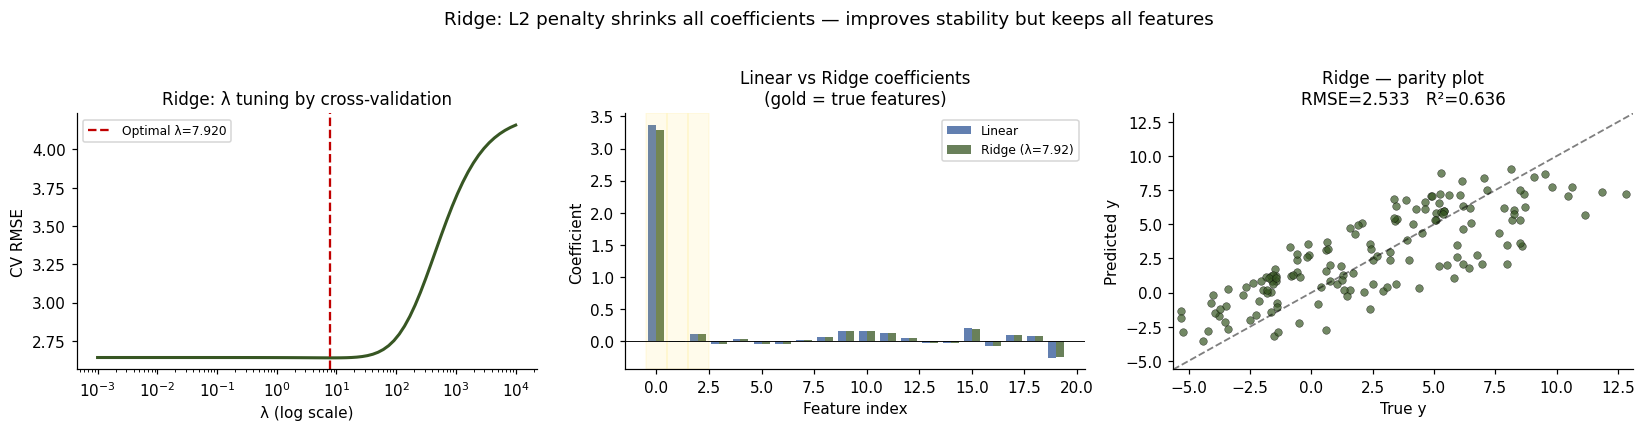

In [ ]:
# ── Ridge Regression — tune λ by cross-validation ────────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=42)
lambdas_r = np.logspace(-3, 4, 80)
ridge_cv = [rmse(y_train, cross_val_predict(Ridge(alpha=l), X_train_s, y_train, cv=kf))
            for l in lambdas_r]
best_lam_r = lambdas_r[np.argmin(ridge_cv)]

ridge = Ridge(alpha=best_lam_r)
ridge.fit(X_train_s, y_train)
pred_ridge = ridge.predict(X_test_s)
rmse_ridge = rmse(y_test, pred_ridge)
r2_ridge   = r2_score(y_test, pred_ridge)

print('Ridge Regression (L2)')
print(f'  β* = (XᵀX + λI)⁻¹ Xᵀy')
print(f'  Optimal λ = {best_lam_r:.4f}  (5-fold CV)')
print(f'  Test RMSE = {rmse_ridge:.4f}   R² = {r2_ridge:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

# λ tuning curve
axes[0].semilogx(lambdas_r, ridge_cv, '-', color='#375623', lw=2)
axes[0].axvline(best_lam_r, color='#C00000', ls='--', lw=1.5, label=f'Optimal λ={best_lam_r:.3f}')
axes[0].set_xlabel('λ (log scale)'); axes[0].set_ylabel('CV RMSE')
axes[0].set_title('Ridge: λ tuning by cross-validation')
axes[0].legend(fontsize=8)

# Coefficient comparison: Linear vs Ridge
x_pos = np.arange(n_features); w = 0.38
axes[1].bar(x_pos - w/2, lin.coef_,   w, label='Linear',           color='#2E5496', alpha=0.75)
axes[1].bar(x_pos + w/2, ridge.coef_, w, label=f'Ridge (λ={best_lam_r:.2f})', color='#375623', alpha=0.75)
for i in range(3):
    axes[1].axvspan(i-0.5, i+0.5, alpha=0.08, color='gold')
axes[1].axhline(0, color='k', lw=0.6)
axes[1].set_xlabel('Feature index'); axes[1].set_ylabel('Coefficient')
axes[1].set_title('Linear vs Ridge coefficients\n(gold = true features)')
axes[1].legend(fontsize=8)

# Parity plot
lims = [y_test.min()-0.3, y_test.max()+0.3]
axes[2].plot(lims, lims, 'k--', lw=1.2, alpha=0.5)
axes[2].scatter(y_test, pred_ridge, color='#375623', s=25, alpha=0.7, edgecolors='k', lw=0.3)
axes[2].set_xlim(lims); axes[2].set_ylim(lims)
axes[2].set_xlabel('True y'); axes[2].set_ylabel('Predicted y')
axes[2].set_title(f'Ridge — parity plot\nRMSE={rmse_ridge:.3f}   R²={r2_ridge:.3f}')

plt.suptitle('Ridge: L2 penalty shrinks all coefficients — improves stability but keeps all features', y=1.02)
plt.tight_layout()
plt.show()

---
## Step 4 — LASSO (L1 Regularisation)

### Mathematics

Replace the L2 penalty with an L1 penalty:
$$L(\boldsymbol{\beta}) = \frac{1}{N}\|\mathbf{X}\boldsymbol{\beta} - \mathbf{y}\|_2^2 + \lambda\|\boldsymbol{\beta}\|_1$$

**No closed-form solution** — solved by coordinate descent. At each step, update one coefficient while holding all others fixed:
$$\beta_j \leftarrow S_\lambda\!\left(\frac{1}{N}\sum_i x_{ij}\left(y_i - \hat{y}_i^{(-j)}\right)\right)$$

where $S_\lambda$ is the **soft-thresholding operator**:
$$S_\lambda(z) = \text{sign}(z)\cdot\max\left(|z| - \lambda,\; 0\right)$$

**Why L1 gives sparsity:** the L1 ball has corners aligned with the coordinate axes. Gradient descent tends to hit these corners, setting coefficients exactly to zero. L2 has a smooth sphere — it shrinks but never zeros.

**Bayesian interpretation:** LASSO = MAP estimate with a Laplace prior $p(\beta_j) \propto e^{-\lambda|\beta_j|}$. You are saying: *"I believe most features are irrelevant."*

**Expected behaviour here:** our problem is sparse (3 of 20 features matter) — LASSO's assumption matches reality for feature selection. But it is still linear — it will zero out noise features but cannot represent the nonlinear components.

LASSO (L1 regularisation)
  Soft-threshold: S_λ(z) = sign(z)·max(|z|−λ, 0)
  Optimal λ = 0.23598  (5-fold CV)
  Non-zero coefficients: 1 / 20  (zeroed out: 19)
  Test RMSE = 2.4812   R² = 0.6511


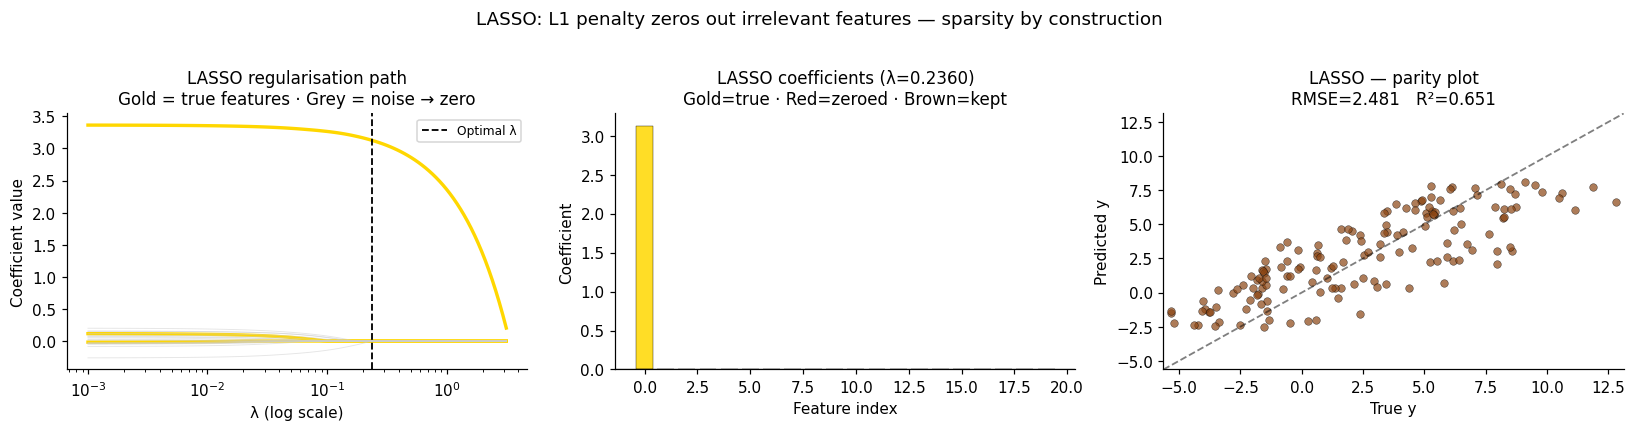


Did LASSO find the true sparse structure?
  Features kept: [1]  (true relevant: [1, 2, 3])


In [ ]:
# ── LASSO — tune λ by cross-validation ───────────────────────────────────────
lambdas_l = np.logspace(-3, 1, 60)
lasso_cv  = [rmse(y_train, cross_val_predict(Lasso(alpha=l, max_iter=10000),
                                              X_train_s, y_train, cv=kf))
             for l in lambdas_l]
best_lam_l = lambdas_l[np.argmin(lasso_cv)]

lasso = Lasso(alpha=best_lam_l, max_iter=10000)
lasso.fit(X_train_s, y_train)
pred_lasso = lasso.predict(X_test_s)
rmse_lasso = rmse(y_test, pred_lasso)
r2_lasso   = r2_score(y_test, pred_lasso)
n_nonzero  = np.sum(np.abs(lasso.coef_) > 1e-6)

print('LASSO (L1 regularisation)')
print(f'  Soft-threshold: S_λ(z) = sign(z)·max(|z|−λ, 0)')
print(f'  Optimal λ = {best_lam_l:.5f}  (5-fold CV)')
print(f'  Non-zero coefficients: {n_nonzero} / {n_features}  (zeroed out: {n_features - n_nonzero})')
print(f'  Test RMSE = {rmse_lasso:.4f}   R² = {r2_lasso:.4f}')

# ── LASSO regularisation path ─────────────────────────────────────────────────
path_lams  = np.logspace(-3, 0.5, 120)
path_coefs = np.array([Lasso(alpha=l, max_iter=10000).fit(X_train_s, y_train).coef_
                       for l in path_lams])

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

# Regularisation path
for i in range(n_features):
    col   = '#FFD700' if i < 3 else '#CCCCCC'
    lw    = 2.2 if i < 3 else 0.6
    alpha = 1.0 if i < 3 else 0.5
    axes[0].semilogx(path_lams, path_coefs[:, i], color=col, lw=lw, alpha=alpha)
axes[0].axvline(best_lam_l, color='k', ls='--', lw=1.2, label='Optimal λ')
axes[0].set_xlabel('λ (log scale)'); axes[0].set_ylabel('Coefficient value')
axes[0].set_title('LASSO regularisation path\nGold = true features · Grey = noise → zero')
axes[0].legend(fontsize=8)

# Coefficient bar
colors_l = ['#FFD700' if i < 3 else ('#C00000' if abs(c) < 1e-6 else '#8B4513')
            for i, c in enumerate(lasso.coef_)]
axes[1].bar(range(n_features), lasso.coef_, color=colors_l, edgecolor='k', lw=0.3, alpha=0.85)
axes[1].axhline(0, color='k', lw=0.8)
axes[1].set_xlabel('Feature index'); axes[1].set_ylabel('Coefficient')
axes[1].set_title(f'LASSO coefficients (λ={best_lam_l:.4f})\nGold=true · Red=zeroed · Brown=kept')

# Parity plot
lims = [y_test.min()-0.3, y_test.max()+0.3]
axes[2].plot(lims, lims, 'k--', lw=1.2, alpha=0.5)
axes[2].scatter(y_test, pred_lasso, color='#8B4513', s=25, alpha=0.7, edgecolors='k', lw=0.3)
axes[2].set_xlim(lims); axes[2].set_ylim(lims)
axes[2].set_xlabel('True y'); axes[2].set_ylabel('Predicted y')
axes[2].set_title(f'LASSO — parity plot\nRMSE={rmse_lasso:.3f}   R²={r2_lasso:.3f}')

plt.suptitle('LASSO: L1 penalty zeros out irrelevant features — sparsity by construction', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nDid LASSO find the true sparse structure?')
kept_features = [i+1 for i in range(n_features) if abs(lasso.coef_[i]) > 1e-6]
print(f'  Features kept: {kept_features}  (true relevant: [1, 2, 3])')

---
## Step 5 — Kernel Ridge Regression (KRR)

### Mathematics — the kernel trick

What if we want an infinite-dimensional feature expansion without computing it? The **kernel trick** lets us work in a high-dimensional space implicitly.

Define a kernel function $k(\mathbf{x}, \mathbf{x}') = \langle \phi(\mathbf{x}), \phi(\mathbf{x}') \rangle$ that computes dot products in a potentially infinite-dimensional feature space without ever computing $\phi$ explicitly.

**RBF (Gaussian) kernel** — corresponds to an *infinite*-dimensional feature space:
$$k(\mathbf{x}, \mathbf{x}') = \exp\!\left(-\gamma\|\mathbf{x} - \mathbf{x}'\|^2\right)$$

**KRR dual solution:** optimise over dual coefficients $\boldsymbol{\alpha}$ instead of weights:
$$\boldsymbol{\alpha}^* = (\mathbf{K} + \lambda \mathbf{I})^{-1} \mathbf{y}, \qquad K_{ij} = k(\mathbf{x}_i, \mathbf{x}_j)$$

**Prediction at new point $\mathbf{x}$:**
$$f(\mathbf{x}) = \sum_{i=1}^N \alpha_i\, k(\mathbf{x}_i, \mathbf{x})$$

The prediction is a weighted sum over **all** training points — closer points (higher $k$) contribute more.

**Physical analogy:** $k(\mathbf{x}, \mathbf{x}')$ is a similarity measure between two material configurations — like a Gaussian overlap integral. Materials similar in feature space are predicted to have similar properties.

**Cost:** $\mathcal{O}(N^3)$ to train (Gram matrix inversion). Scales poorly for large $N$, but excellent for small-to-medium physically-motivated datasets.

Kernel Ridge Regression (RBF kernel)
  k(x,x') = exp(−γ‖x−x'‖²)
  α* = (K + λI)⁻¹ y     [dual, N×N system]
  f(x) = Σᵢ αᵢ k(xᵢ, x) [weighted sum over training points]
  Optimal γ=0.01, λ=0.001  (grid search + CV)
  Test RMSE = 1.5795   R² = 0.8586


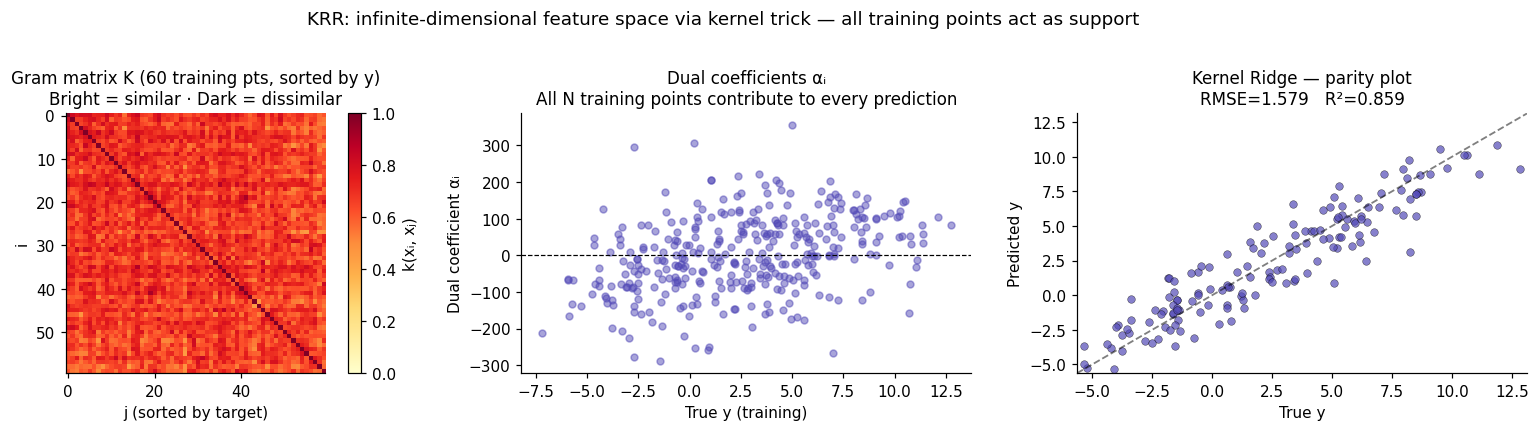


Note: with 20 features of which 17 are noise, the distance ‖x−x'‖² is dominated
by the 17 noise features. This dilutes the signal in the kernel — a known weakness.


In [ ]:
# ── Kernel Ridge Regression — grid search over γ and λ ───────────────────────
best_rmse_krr, best_krr = np.inf, None
best_params_krr = {}

for gamma in [0.01, 0.05, 0.1, 0.3, 0.6, 1.0, 2.0]:
    for alpha in [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]:
        preds = cross_val_predict(
            KernelRidge(alpha=alpha, kernel='rbf', gamma=gamma),
            X_train_s, y_train, cv=kf)
        r = rmse(y_train, preds)
        if r < best_rmse_krr:
            best_rmse_krr = r
            best_params_krr = {'alpha': alpha, 'gamma': gamma}

krr = KernelRidge(kernel='rbf', **best_params_krr)
krr.fit(X_train_s, y_train)
pred_krr = krr.predict(X_test_s)
rmse_krr = rmse(y_test, pred_krr)
r2_krr   = r2_score(y_test, pred_krr)

print('Kernel Ridge Regression (RBF kernel)')
print(f'  k(x,x\') = exp(−γ‖x−x\'‖²)')
print(f'  α* = (K + λI)⁻¹ y     [dual, N×N system]')
print(f'  f(x) = Σᵢ αᵢ k(xᵢ, x) [weighted sum over training points]')
print(f'  Optimal γ={best_params_krr["gamma"]}, λ={best_params_krr["alpha"]}  (grid search + CV)')
print(f'  Test RMSE = {rmse_krr:.4f}   R² = {r2_krr:.4f}')

# ── Visualise Gram matrix + parity plot ───────────────────────────────────────
from sklearn.metrics.pairwise import rbf_kernel

K_vis = rbf_kernel(X_train_s[:60], X_train_s[:60], gamma=best_params_krr['gamma'])
sort_idx = np.argsort(y_train[:60])
K_sorted = K_vis[np.ix_(sort_idx, sort_idx)]

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

im = axes[0].imshow(K_sorted, cmap='YlOrRd', vmin=0, vmax=1)
plt.colorbar(im, ax=axes[0], label='k(xᵢ, xⱼ)')
axes[0].set_title('Gram matrix K (60 training pts, sorted by y)\nBright = similar · Dark = dissimilar')
axes[0].set_xlabel('j (sorted by target)'); axes[0].set_ylabel('i')

# Dual coefficients vs true y
axes[1].scatter(y_train, krr.dual_coef_.flatten(), alpha=0.5, s=20, color='#534AB7')
axes[1].axhline(0, color='k', lw=0.8, ls='--')
axes[1].set_xlabel('True y (training)'); axes[1].set_ylabel('Dual coefficient αᵢ')
axes[1].set_title('Dual coefficients αᵢ\nAll N training points contribute to every prediction')

# Parity plot
lims = [y_test.min()-0.3, y_test.max()+0.3]
axes[2].plot(lims, lims, 'k--', lw=1.2, alpha=0.5)
axes[2].scatter(y_test, pred_krr, color='#534AB7', s=25, alpha=0.7, edgecolors='k', lw=0.3)
axes[2].set_xlim(lims); axes[2].set_ylim(lims)
axes[2].set_xlabel('True y'); axes[2].set_ylabel('Predicted y')
axes[2].set_title(f'Kernel Ridge — parity plot\nRMSE={rmse_krr:.3f}   R²={r2_krr:.3f}')

plt.suptitle('KRR: infinite-dimensional feature space via kernel trick — all training points act as support', y=1.02)
plt.tight_layout()
plt.show()

print('\nNote: with 20 features of which 17 are noise, the distance ‖x−x\'‖² is dominated')
print('by the 17 noise features. This dilutes the signal in the kernel — a known weakness.')

---
## Step 6 — Random Forest

### Mathematics

A Random Forest is an ensemble of decision trees, each trained on a **bootstrap sample** with a **random subset of features** at each split.

**A single tree split** chooses feature $j$ and threshold $s$ that minimises within-leaf variance:
$$\min_{j,\, s}\; \left[\sum_{i \in R_L(j,s)} (y_i - \bar{y}_L)^2 + \sum_{i \in R_R(j,s)} (y_i - \bar{y}_R)^2\right]$$

**Forest prediction** — average over $T$ trees:
$$f(\mathbf{x}) = \frac{1}{T}\sum_{t=1}^T f_t(\mathbf{x})$$

**Why averaging helps — bias-variance decomposition:**
$$\underbrace{\text{MSE}(f)}_{\text{total error}} = \underbrace{(\mathbb{E}[f]-g)^2}_{\text{Bias}^2} + \underbrace{\mathbb{E}[(f-\mathbb{E}[f])^2]}_{\text{Variance}} + \sigma^2$$

Each deep tree: low bias (fits complex functions) + high variance (sensitive to data). Average of $T$ uncorrelated trees: variance $\to$ variance$/ T$. The random feature subsampling decorrelates the trees.

**Inductive bias:** $g(\mathbf{x})$ is piecewise constant — approximated by axis-aligned rectangular regions. No smoothness assumption. Naturally handles nonlinearity and interactions. **No feature scaling needed** — splits are rank-based.

Random Forest
  f(x) = (1/T) Σ fₜ(x)  [T=300 trees]
  No feature scaling needed — splits are scale-invariant
  Test RMSE = 1.0445   R² = 0.9382
  True features in RF top-3: 3/3


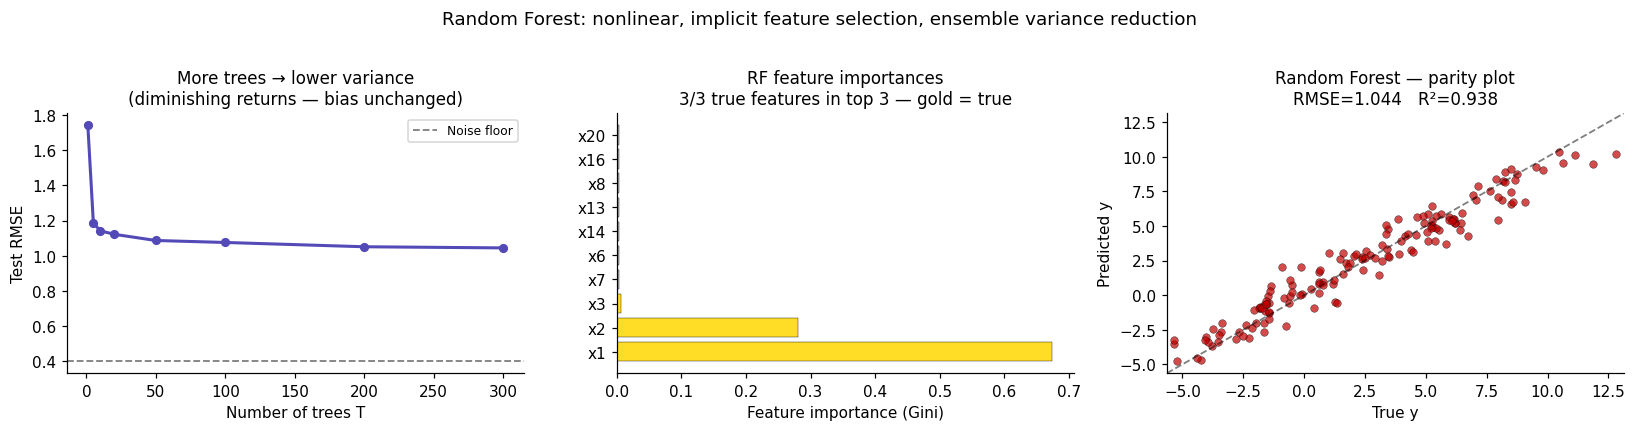

In [ ]:
# ── Random Forest ─────────────────────────────────────────────────────────────
# Note: use raw X (not scaled) — RF is scale-invariant
rf = RandomForestRegressor(n_estimators=300, max_depth=8,
                            min_samples_leaf=3, random_state=1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
rmse_rf = rmse(y_test, pred_rf)
r2_rf   = r2_score(y_test, pred_rf)

print('Random Forest')
print(f'  f(x) = (1/T) Σ fₜ(x)  [T=300 trees]')
print(f'  No feature scaling needed — splits are scale-invariant')
print(f'  Test RMSE = {rmse_rf:.4f}   R² = {r2_rf:.4f}')

importances = rf.feature_importances_
sort_fi = np.argsort(importances)[::-1]
top3 = sum(1 for i in sort_fi[:3] if i < 3)
print(f'  True features in RF top-3: {top3}/3')

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

# Bias-variance: n_trees vs RMSE
tree_counts = [1, 5, 10, 20, 50, 100, 200, 300]
rmse_trees = []
for nt in tree_counts:
    rf_t = RandomForestRegressor(n_estimators=nt, max_depth=8, min_samples_leaf=3, random_state=1)
    rf_t.fit(X_train, y_train)
    rmse_trees.append(rmse(y_test, rf_t.predict(X_test)))

axes[0].plot(tree_counts, rmse_trees, 'o-', color='#534AB7', lw=2, ms=5)
axes[0].axhline(noise_level, color='gray', ls='--', lw=1.2, label='Noise floor')
axes[0].set_xlabel('Number of trees T'); axes[0].set_ylabel('Test RMSE')
axes[0].set_title('More trees → lower variance\n(diminishing returns — bias unchanged)')
axes[0].legend(fontsize=8)

# Feature importances
colors_fi = ['#FFD700' if i < 3 else '#AAAAAA' for i in sort_fi[:10]]
axes[1].barh([f'x{i+1}' for i in sort_fi[:10]], importances[sort_fi[:10]],
             color=colors_fi, alpha=0.85, edgecolor='k', lw=0.3)
axes[1].set_xlabel('Feature importance (Gini)')
axes[1].set_title(f'RF feature importances\n{top3}/3 true features in top 3 — gold = true')

# Parity plot
lims = [y_test.min()-0.3, y_test.max()+0.3]
axes[2].plot(lims, lims, 'k--', lw=1.2, alpha=0.5)
axes[2].scatter(y_test, pred_rf, color='#C00000', s=25, alpha=0.7, edgecolors='k', lw=0.3)
axes[2].set_xlim(lims); axes[2].set_ylim(lims)
axes[2].set_xlabel('True y'); axes[2].set_ylabel('Predicted y')
axes[2].set_title(f'Random Forest — parity plot\nRMSE={rmse_rf:.3f}   R²={r2_rf:.3f}')

plt.suptitle('Random Forest: nonlinear, implicit feature selection, ensemble variance reduction', y=1.02)
plt.tight_layout()
plt.show()

---
## Step 7 — Neural Network (MLP)

### Mathematics

**Model:** composition of linear transforms and nonlinearities across $L$ layers:
$$f(\mathbf{x};\boldsymbol{\Theta}) = \mathbf{W}_L\,\sigma\!\left(\mathbf{W}_{L-1}\,\sigma\!\left(\cdots\,\sigma(\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1)\cdots\right) + \mathbf{b}_{L-1}\right) + \mathbf{b}_L$$

**Training — gradient descent:** update parameters in the direction of steepest loss descent:
$$\mathbf{W}_k \leftarrow \mathbf{W}_k - \eta\,\frac{\partial L}{\partial \mathbf{W}_k}$$

**Backpropagation** computes all gradients in one reverse pass via the chain rule:
$$\frac{\partial L}{\partial \mathbf{W}_k} = \frac{\partial L}{\partial \mathbf{a}_L}\cdot\frac{\partial \mathbf{a}_L}{\partial \mathbf{a}_{L-1}}\cdots\frac{\partial \mathbf{a}_{k+1}}{\partial \mathbf{W}_k}$$

**Universal approximation theorem:** a single hidden layer of sufficient width can approximate any continuous function — but this does not guarantee that gradient descent finds it with finite data.

**Inductive bias:** very weak — neural networks can represent almost anything. This is powerful for large datasets, but can overfit badly on small ones without careful regularisation.

Neural Network (MLP, ReLU activation)
  Architecture: 20 → (80, 40) → 1
  L2 regularisation α = 0.1
  Total parameters: 4961  vs  N_train = 350
  Test RMSE = 1.6052   R² = 0.8540


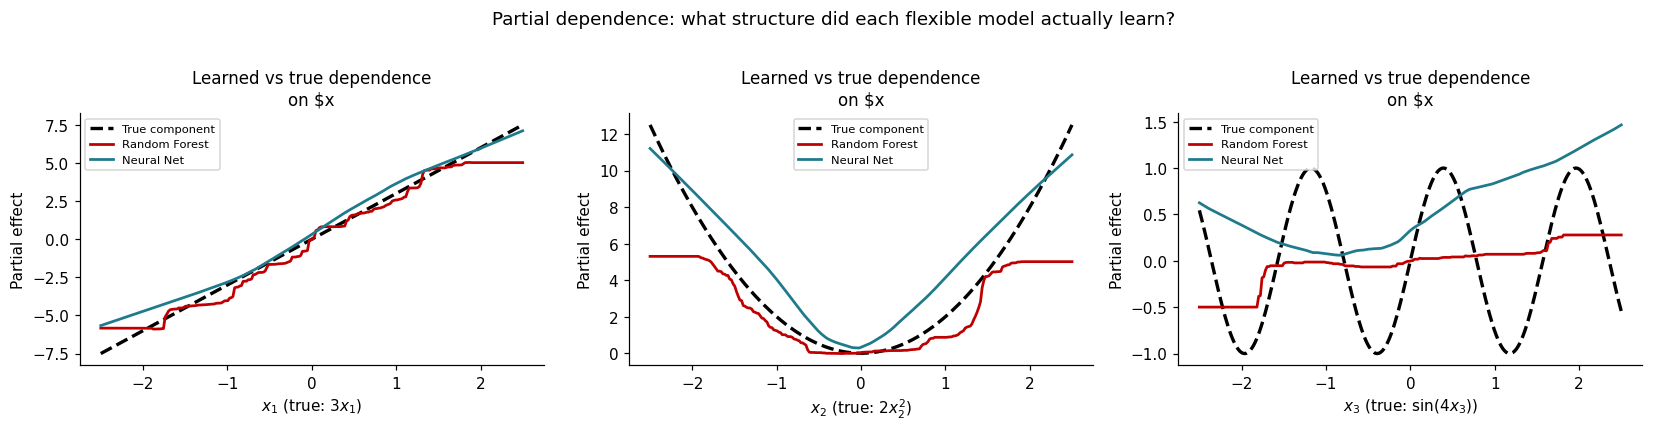

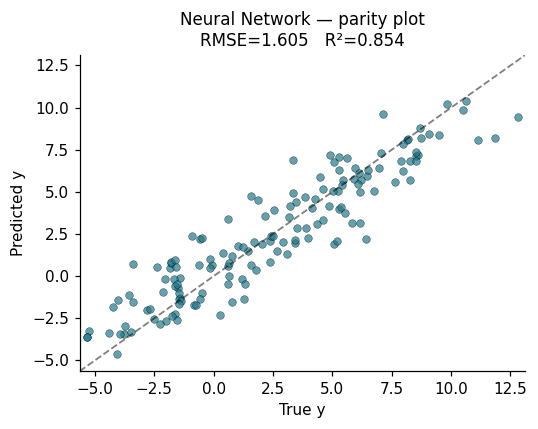

In [ ]:
# ── Neural Network — tune architecture and regularisation ─────────────────────
best_rmse_nn, best_params_nn = np.inf, {}

for hidden in [(40,), (80,), (40, 20), (80, 40)]:
    for alpha_nn in [0.0001, 0.001, 0.01, 0.1]:
        nn_cv = MLPRegressor(hidden_layer_sizes=hidden, activation='relu',
                              alpha=alpha_nn, max_iter=2000, random_state=1,
                              early_stopping=True, learning_rate_init=0.001)
        preds = cross_val_predict(nn_cv, X_train_s, y_train, cv=kf)
        r = rmse(y_train, preds)
        if r < best_rmse_nn:
            best_rmse_nn = r
            best_params_nn = {'hidden_layer_sizes': hidden, 'alpha': alpha_nn}

nn = MLPRegressor(**best_params_nn, activation='relu', max_iter=4000,
                   random_state=1, learning_rate_init=0.001)
nn.fit(X_train_s, y_train)
pred_nn = nn.predict(X_test_s)
rmse_nn = rmse(y_test, pred_nn)
r2_nn   = r2_score(y_test, pred_nn)
n_params = sum(w.size for w in nn.coefs_) + sum(b.size for b in nn.intercepts_)

print('Neural Network (MLP, ReLU activation)')
print(f'  Architecture: 20 → {best_params_nn["hidden_layer_sizes"]} → 1')
print(f'  L2 regularisation α = {best_params_nn["alpha"]}')
print(f'  Total parameters: {n_params}  vs  N_train = {len(y_train)}')
print(f'  Test RMSE = {rmse_nn:.4f}   R² = {r2_nn:.4f}')

# ── What did each model learn for the three components? ───────────────────────
x_grid = np.linspace(-2.5, 2.5, 250)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
components_pd = [
    (0, r'$x_1$ (true: $3x_1$)',          lambda x: 3*x),
    (1, r'$x_2$ (true: $2x_2^2$)',         lambda x: 2*x**2),
    (2, r'$x_3$ (true: $\sin(4x_3)$)',     lambda x: np.sin(4*x)),
]

for ax, (fi, label, true_fn) in zip(axes, components_pd):
    X_pd = np.zeros((250, n_features))       # all other features = 0
    X_pd[:, fi] = x_grid
    X_pd_s = scaler.transform(X_pd)

    y_true_pd = true_fn(x_grid)
    y_rf_pd   = rf.predict(X_pd) - rf.predict(np.zeros((1, n_features)))[0]
    y_nn_pd   = nn.predict(X_pd_s) - nn.predict(np.zeros((1, n_features)))[0]

    ax.plot(x_grid, y_true_pd, 'k--', lw=2.2, label='True component')
    ax.plot(x_grid, y_rf_pd,   color='#C00000', lw=1.8, label='Random Forest')
    ax.plot(x_grid, y_nn_pd,   color='#1F7A8C', lw=1.8, label='Neural Net')
    ax.set_xlabel(label); ax.set_ylabel('Partial effect')
    ax.set_title(f'Learned vs true dependence\non {label[:2]}')
    ax.legend(fontsize=7.5)

plt.suptitle('Partial dependence: what structure did each flexible model actually learn?', y=1.02)
plt.tight_layout()
plt.show()

# Parity plot
fig, ax = plt.subplots(figsize=(5, 4))
lims = [y_test.min()-0.3, y_test.max()+0.3]
ax.plot(lims, lims, 'k--', lw=1.2, alpha=0.5)
ax.scatter(y_test, pred_nn, color='#1F7A8C', s=25, alpha=0.7, edgecolors='k', lw=0.3)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('True y'); ax.set_ylabel('Predicted y')
ax.set_title(f'Neural Network — parity plot\nRMSE={rmse_nn:.3f}   R²={r2_nn:.3f}')
plt.tight_layout()
plt.show()

---
## Step 8 — Full Comparison

All six algorithms on the same train/test split. One summary panel.

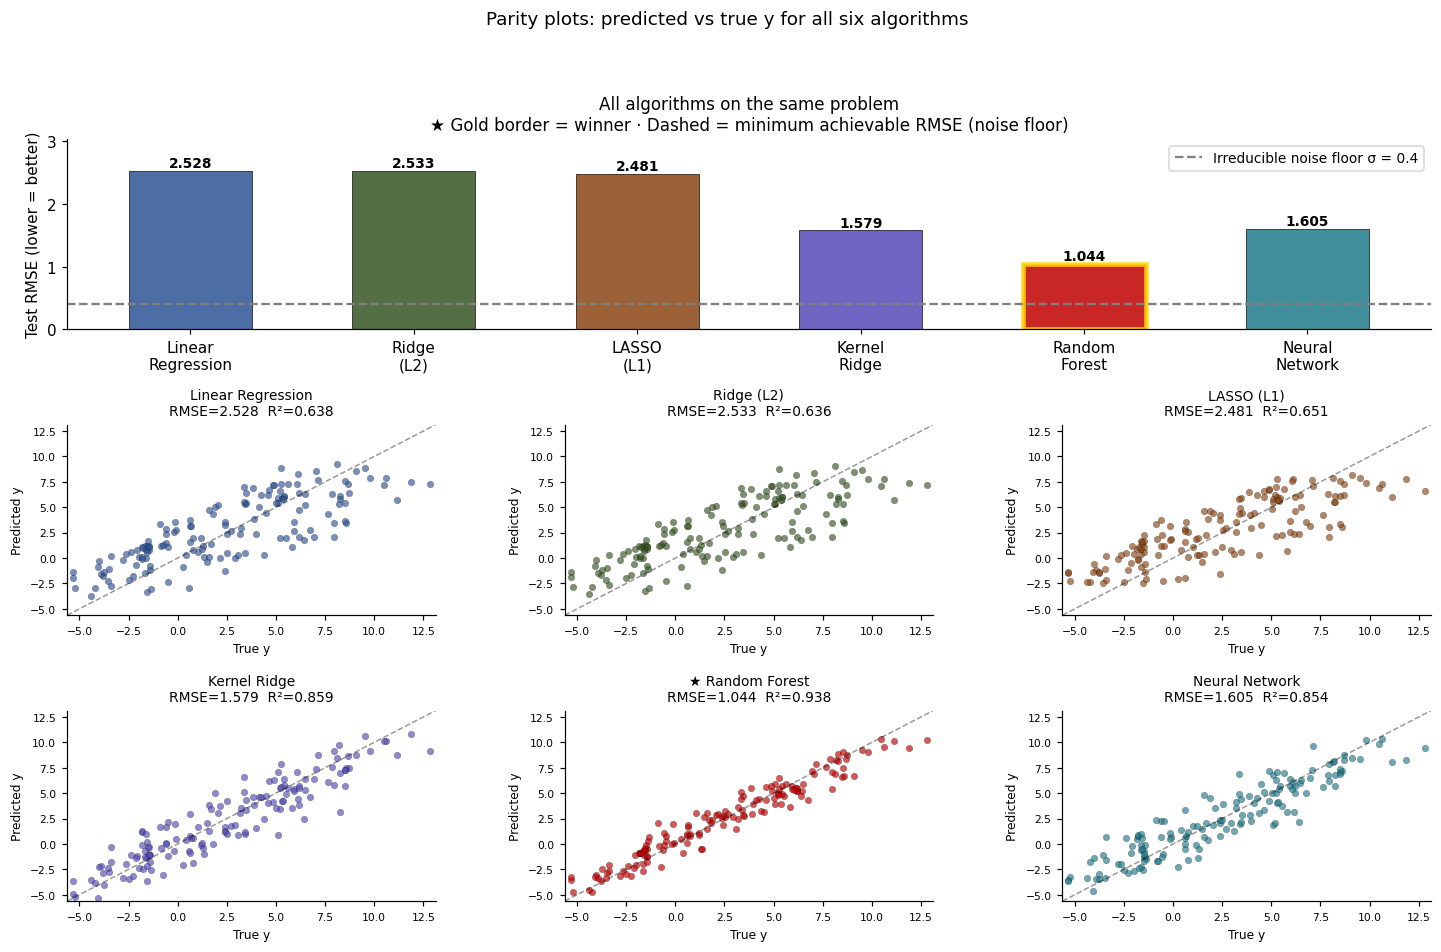


══════════════════════════════════════════════════════════
  Algorithm             RMSE     R²       Gap above noise
──────────────────────────────────────────────────────────
  Random Forest         1.0445  +0.9382  +0.6445 ← WINNER
  Kernel Ridge          1.5795  +0.8586  +1.1795
  Neural Network        1.6052  +0.8540  +1.2052
  LASSO (L1)            2.4812  +0.6511  +2.0812
  Linear Regression     2.5281  +0.6377  +2.1281
  Ridge (L2)            2.5327  +0.6364  +2.1327
  Noise floor           0.4000  (theoretical minimum)
══════════════════════════════════════════════════════════


In [ ]:
# ── Compile all results ───────────────────────────────────────────────────────
results = {
    'Linear\nRegression': (pred_lin,   rmse_lin,  r2_lin,   '#2E5496'),
    'Ridge\n(L2)':        (pred_ridge, rmse_ridge, r2_ridge, '#375623'),
    'LASSO\n(L1)':        (pred_lasso, rmse_lasso, r2_lasso, '#8B4513'),
    'Kernel\nRidge':      (pred_krr,   rmse_krr,  r2_krr,   '#534AB7'),
    'Random\nForest':     (pred_rf,    rmse_rf,   r2_rf,    '#C00000'),
    'Neural\nNetwork':    (pred_nn,    rmse_nn,   r2_nn,    '#1F7A8C'),
}

names      = list(results.keys())
preds_all  = [v[0] for v in results.values()]
rmses_all  = [v[1] for v in results.values()]
r2s_all    = [v[2] for v in results.values()]
cols_all   = [v[3] for v in results.values()]
best_idx   = int(np.argmin(rmses_all))
lims       = [y_test.min()-0.3, y_test.max()+0.3]

fig = plt.figure(figsize=(16, 9))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)

# Top row spanning all columns: RMSE bar chart
ax_bar = fig.add_subplot(gs[0, :])
bars = ax_bar.bar(names, rmses_all, color=cols_all, alpha=0.85, edgecolor='k', lw=0.5, width=0.55)
bars[best_idx].set_edgecolor('#FFD700'); bars[best_idx].set_linewidth(3)
ax_bar.axhline(noise_level, color='gray', ls='--', lw=1.5,
               label=f'Irreducible noise floor σ = {noise_level}')
for bar, r in zip(bars, rmses_all):
    ax_bar.text(bar.get_x() + bar.get_width()/2, r + 0.01,
                f'{r:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax_bar.set_ylabel('Test RMSE (lower = better)', fontsize=10)
ax_bar.set_title('All algorithms on the same problem\n'
                 '★ Gold border = winner · Dashed = minimum achievable RMSE (noise floor)', fontsize=11)
ax_bar.legend(fontsize=9)
ax_bar.set_ylim(0, max(rmses_all) * 1.2)

# Bottom two rows: individual parity plots
positions = [(1,0),(1,1),(1,2),(2,0),(2,1),(2,2)]
for (row, col), name, pred_v, col_c, rmse_v, r2_v in zip(
        positions, names, preds_all, cols_all, rmses_all, r2s_all):
    ax = fig.add_subplot(gs[row, col])
    ax.plot(lims, lims, 'k--', lw=1, alpha=0.4)
    ax.scatter(y_test, pred_v, c=col_c, s=18, alpha=0.65, edgecolors='k', lw=0.2)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('True y', fontsize=8); ax.set_ylabel('Predicted y', fontsize=8)
    ax.tick_params(labelsize=7)
    star = '★ ' if rmse_v == min(rmses_all) else ''
    ax.set_title(f'{star}{name.replace(chr(10)," ")}\nRMSE={rmse_v:.3f}  R²={r2_v:.3f}', fontsize=9)

plt.suptitle('Parity plots: predicted vs true y for all six algorithms', fontsize=12, y=1.01)
plt.show()

# Summary table
print('\n══════════════════════════════════════════════════════════')
print(f'  {"Algorithm":20s}  {"RMSE":7s}  {"R²":7s}  {"Gap above noise"}')
print('──────────────────────────────────────────────────────────')
for name, rmse_v, r2_v in sorted(zip(names, rmses_all, r2s_all), key=lambda x: x[1]):
    marker = ' ← WINNER' if rmse_v == min(rmses_all) else ''
    print(f'  {name.replace(chr(10)," "):20s}  {rmse_v:.4f}  {r2_v:+.4f}  +{rmse_v-noise_level:.4f}{marker}')
print(f'  {"Noise floor":20s}  {noise_level:.4f}  (theoretical minimum)')
print('══════════════════════════════════════════════════════════')

---
## Step 9 — The NFL Proof: Change the Problem, Watch the Winner Change

The NFL theorem says no algorithm wins on *all* problems. We test four different data-generating processes:

| Problem | True function | Which assumption matches? | Expected winner |
|---|---|---|---|
| A — original | $3x_1 + 2x_2^2 + \sin(4x_3)$ | Nonlinear + sparse | RF or NN |
| B — linear sparse | $5x_1 - 2x_2 + 0.2\varepsilon$ | Linear + sparse | LASSO |
| C — linear dense | $\sum_{j=1}^{20} x_j + 0.2\varepsilon$ | Linear + all features matter | Ridge |
| D — smooth | $\exp(-\|x\|^2/4)$ (Gaussian) | Smooth, symmetric | Kernel Ridge |

In [ ]:
# ── Four different data-generating processes ──────────────────────────────────
N2 = 500
X2 = np.random.uniform(-2, 2, (N2, 20))

problems = {
    'A: nonlinear\n+ sparse':  y,       # original dataset, same X
    'B: linear\n+ sparse':     5*X2[:, 0] - 2*X2[:, 1] + 0.2*np.random.randn(N2),
    'C: linear\n+ dense':      X2.sum(axis=1) + 0.2*np.random.randn(N2),
    'D: smooth\n(Gaussian)':   np.exp(-np.sum(X2[:, :3]**2, axis=1) / 4) + 0.1*np.random.randn(N2),
}

def run_all(X_tr, y_tr, X_te, y_te):
    """Fit all 6 models and return RMSE dict."""
    sc = StandardScaler()
    Xtr_s = sc.fit_transform(X_tr)
    Xte_s = sc.transform(X_te)
    out = {}
    for name, m, scaled in [
        ('Linear',      LinearRegression(), True),
        ('Ridge',       Ridge(alpha=1.0), True),
        ('LASSO',       Lasso(alpha=0.05, max_iter=5000), True),
        ('KernelRidge', KernelRidge(alpha=0.1, kernel='rbf', gamma=0.3), True),
        ('RandomForest',RandomForestRegressor(n_estimators=200, max_depth=6,
                                              min_samples_leaf=3, random_state=1), False),
        ('NeuralNet',   MLPRegressor(hidden_layer_sizes=(40, 20), alpha=0.01,
                                      max_iter=3000, random_state=1), True),
    ]:
        Xtr_use = Xtr_s if scaled else X_tr
        Xte_use = Xte_s if scaled else X_te
        m.fit(Xtr_use, y_tr)
        out[name] = rmse(y_te, m.predict(Xte_use))
    return out

print('Running all 6 models on 4 different problems...')
all_res = {}
for prob_label, y_prob in problems.items():
    X_use = X if 'nonlinear' in prob_label else X2
    Xtr, Xte, ytr, yte = train_test_split(X_use, y_prob, test_size=0.3, random_state=1)
    baseline = rmse(yte, np.full_like(yte, ytr.mean()))
    res = run_all(Xtr, ytr, Xte, yte)
    all_res[prob_label] = {'rmse': res, 'baseline': baseline}
    print(f'  {prob_label.replace(chr(10)," "):30s}: winner = {min(res, key=res.get):12s} '
          f'(RMSE={min(res.values()):.3f})')

print('Done.')

Running all 6 models on 4 different problems...
  A: nonlinear + sparse         : winner = RandomForest (RMSE=1.080)
  B: linear + sparse            : winner = LASSO        (RMSE=0.192)
  C: linear + dense             : winner = Linear       (RMSE=0.216)
  D: smooth (Gaussian)          : winner = RandomForest (RMSE=0.144)
Done.


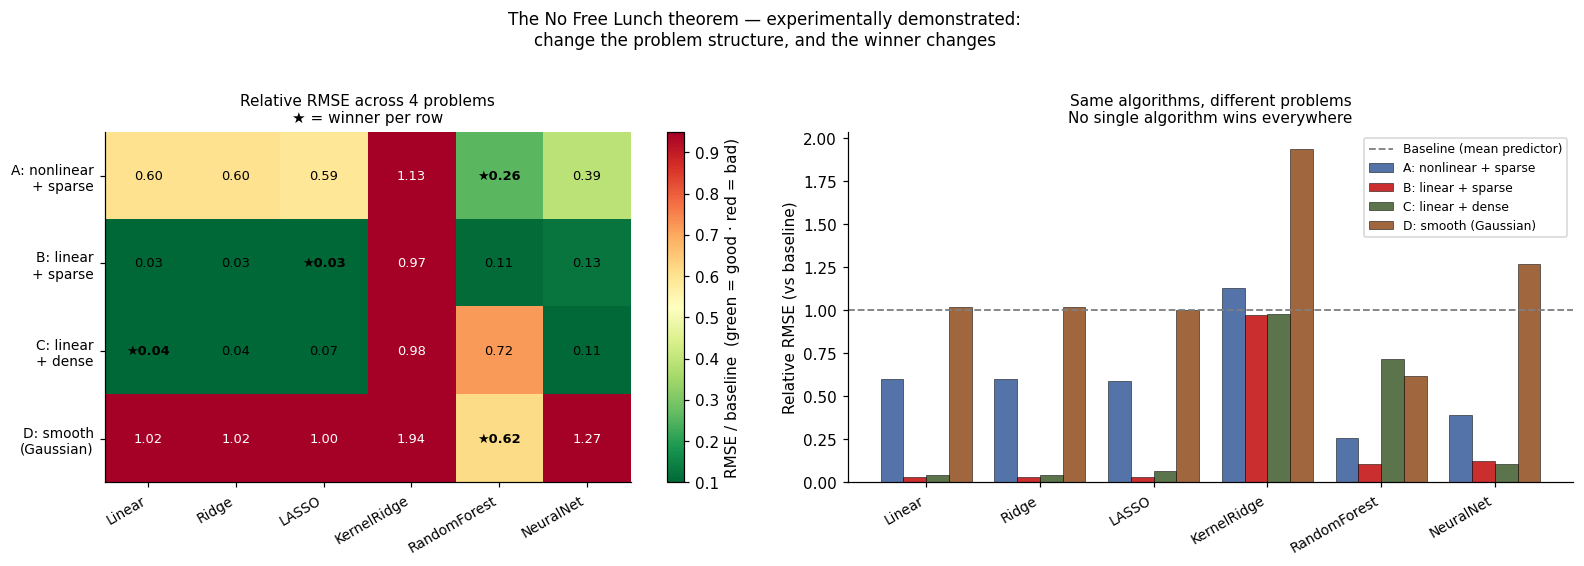

Winners:
  A: nonlinear + sparse         : RandomForest     (rel. RMSE = 0.257)
  B: linear + sparse            : LASSO            (rel. RMSE = 0.032)
  C: linear + dense             : Linear           (rel. RMSE = 0.041)
  D: smooth (Gaussian)          : RandomForest     (rel. RMSE = 0.617)


In [ ]:
# ── Visualise: NFL — winner changes with the problem ──────────────────────────
model_names   = ['Linear', 'Ridge', 'LASSO', 'KernelRidge', 'RandomForest', 'NeuralNet']
prob_labels   = list(all_res.keys())
n_models      = len(model_names)
n_probs       = len(prob_labels)

# Build relative RMSE matrix (relative to baseline mean predictor)
rmse_rel = np.array([
    [all_res[p]['rmse'][m] / all_res[p]['baseline'] for m in model_names]
    for p in prob_labels
])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: heatmap ─────────────────────────────────────────────────────────────
im = axes[0].imshow(rmse_rel, cmap='RdYlGn_r', vmin=0.1, vmax=0.95)
axes[0].set_xticks(range(n_models))
axes[0].set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
axes[0].set_yticks(range(n_probs))
axes[0].set_yticklabels(prob_labels, fontsize=9)
plt.colorbar(im, ax=axes[0], label='RMSE / baseline  (green = good · red = bad)')

for i in range(n_probs):
    best_j = int(np.argmin(rmse_rel[i]))
    for j in range(n_models):
        val = rmse_rel[i, j]
        star = '★' if j == best_j else ''
        axes[0].text(j, i, f'{star}{val:.2f}', ha='center', va='center',
                     fontsize=8.5, fontweight='bold' if j == best_j else 'normal',
                     color='white' if val > 0.75 else 'black')

axes[0].set_title('Relative RMSE across 4 problems\n★ = winner per row', fontsize=10)

# ── Right: grouped bar chart ───────────────────────────────────────────────────
x_pos  = np.arange(n_models)
width  = 0.20
prob_cols = ['#2E5496', '#C00000', '#375623', '#8B4513']

for pi, (prob_label, col) in enumerate(zip(prob_labels, prob_cols)):
    offset = (pi - 1.5) * width
    axes[1].bar(x_pos + offset, rmse_rel[pi], width,
                label=prob_label.replace('\n', ' '), color=col, alpha=0.82,
                edgecolor='k', lw=0.4)

axes[1].axhline(1.0, color='gray', ls='--', lw=1.2, label='Baseline (mean predictor)')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
axes[1].set_ylabel('Relative RMSE (vs baseline)')
axes[1].set_title('Same algorithms, different problems\nNo single algorithm wins everywhere', fontsize=10)
axes[1].legend(fontsize=8, loc='upper right')

plt.suptitle('The No Free Lunch theorem — experimentally demonstrated:\n'
             'change the problem structure, and the winner changes',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print('Winners:')
for i, p in enumerate(prob_labels):
    best_j = int(np.argmin(rmse_rel[i]))
    print(f'  {p.replace(chr(10)," "):30s}: {model_names[best_j]:15s}  '
          f'(rel. RMSE = {rmse_rel[i, best_j]:.3f})')

---
## Step 10 — Extrapolation Stress Test

All models were trained on $x \in [-2, 2]$. We now ask for predictions at $x \in [2, 4]$ — a region never seen in training.

**This is the most important test for physical sciences ML.** Novel compositions, extreme conditions, and unexplored phases all live in the extrapolation regime.

Model            Interp RMSE   Extrap RMSE   Degradation
────────────────────────────────────────────────────────
Linear           2.5281        16.6605        6.6×
Ridge            2.5327        16.8394        6.6×
LASSO            2.4812        18.4175        7.4×
KernelRidge      1.5795        20.5500        13.0×
RandomForest     1.0445        18.7443        17.9×
NeuralNet        1.6052        14.9358        9.3×


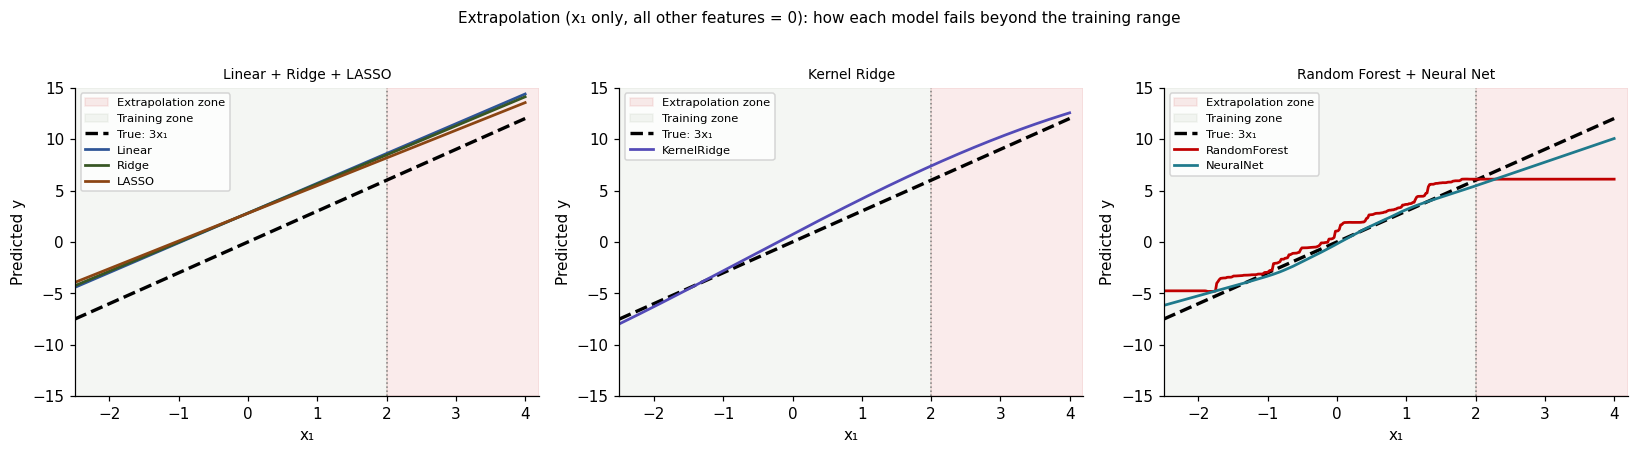


Extrapolation failure modes:
  Linear models:  extrapolate linearly — correct for x₁ but wrong for x₂, x₃
  Kernel Ridge:   decays toward zero far from training data (RBF similarity → 0)
  Random Forest:  freezes at boundary — predicts the nearest leaf value
  Neural Net:     unpredictable — can grow, decay, or oscillate
  None of them knows they are extrapolating — no internal alarm.


In [ ]:
# ── Extrapolation test ────────────────────────────────────────────────────────
X_extra   = np.random.uniform(2, 4, (200, n_features))
y_extra   = true_function(X_extra)          # no noise — pure extrapolation test
X_extra_s = scaler.transform(X_extra)

extra_preds = {
    'Linear':       lin.predict(X_extra_s),
    'Ridge':        ridge.predict(X_extra_s),
    'LASSO':        lasso.predict(X_extra_s),
    'KernelRidge':  krr.predict(X_extra_s),
    'RandomForest': rf.predict(X_extra),
    'NeuralNet':    nn.predict(X_extra_s),
}

print(f'{"Model":15s}  {"Interp RMSE":12s}  {"Extrap RMSE":12s}  {"Degradation"}')
print('─' * 56)
interp_rmses = dict(zip(
    ['Linear','Ridge','LASSO','KernelRidge','RandomForest','NeuralNet'],
    [rmse_lin, rmse_ridge, rmse_lasso, rmse_krr, rmse_rf, rmse_nn]
))
for name, pred_e in extra_preds.items():
    r_e = rmse(y_extra, pred_e)
    r_i = interp_rmses[name]
    print(f'{name:15s}  {r_i:.4f}        {r_e:.4f}        {r_e/r_i:.1f}×')

# ── 1D extrapolation visualisation ────────────────────────────────────────────
x1_grid  = np.linspace(-2.5, 4.0, 350)
X_1d     = np.zeros((350, n_features))
X_1d[:, 0] = x1_grid           # vary x₁ only; true effect = 3x₁
X_1d_s   = scaler.transform(X_1d)
y_1d_true = 3 * x1_grid

model_preds_1d = [
    ('Linear + Ridge + LASSO', [
        ('Linear', lin.predict(X_1d_s), '#2E5496'),
        ('Ridge',  ridge.predict(X_1d_s), '#375623'),
        ('LASSO',  lasso.predict(X_1d_s), '#8B4513'),
    ]),
    ('Kernel Ridge', [
        ('KernelRidge', krr.predict(X_1d_s), '#534AB7'),
    ]),
    ('Random Forest + Neural Net', [
        ('RandomForest', rf.predict(X_1d), '#C00000'),
        ('NeuralNet',    nn.predict(X_1d_s), '#1F7A8C'),
    ]),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (title, model_list) in zip(axes, model_preds_1d):
    ax.axvspan(2, 4.2, alpha=0.08, color='#C00000', label='Extrapolation zone')
    ax.axvspan(-2.5, 2, alpha=0.05, color='#375623', label='Training zone')
    ax.axvline(2, color='gray', lw=1, ls=':')
    ax.plot(x1_grid, y_1d_true, 'k--', lw=2.2, label='True: 3x₁')
    for name, p1d, col in model_list:
        ax.plot(x1_grid, p1d, '-', color=col, lw=1.8, label=name)
    ax.set_xlim(-2.5, 4.2); ax.set_ylim(-15, 15)
    ax.set_xlabel('x₁'); ax.set_ylabel('Predicted y')
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7.5)

plt.suptitle('Extrapolation (x₁ only, all other features = 0): how each model fails beyond the training range',
             y=1.02, fontsize=10)
plt.tight_layout()
plt.show()

print('\nExtrapolation failure modes:')
print('  Linear models:  extrapolate linearly — correct for x₁ but wrong for x₂, x₃')
print('  Kernel Ridge:   decays toward zero far from training data (RBF similarity → 0)')
print('  Random Forest:  freezes at boundary — predicts the nearest leaf value')
print('  Neural Net:     unpredictable — can grow, decay, or oscillate')
print('  None of them knows they are extrapolating — no internal alarm.')

---
## Summary — The No Free Lunch Theorem

| Algorithm | Inductive bias | Wins when | Fails when |
|---|---|---|---|
| **Linear regression** | $g(x)$ is a hyperplane | Truly linear | Any nonlinearity |
| **Ridge (L2)** | Linear + small weights | Linear + noisy / collinear features | Nonlinearity |
| **LASSO (L1)** | Linear + sparse | Linear + few features matter | Nonlinearity; correlated features |
| **Kernel Ridge (RBF)** | Smooth in RKHS | Nonlinear + smooth + moderate N | Large N (O(N³)); high-dim noise |
| **Random Forest** | Piecewise constant | Nonlinear + interactions + large N | Extrapolation; smooth functions |
| **Neural Network** | Learnable hierarchy | Complex + very large N | Small N without regularisation |

---

**The NFL theorem — stated precisely:**

For any two algorithms $A$ and $B$, averaged uniformly over all possible target functions $g$:
$$\mathbb{E}_g[\text{Error}(A, g)] = \mathbb{E}_g[\text{Error}(B, g)]$$

**What this means for physical sciences:** You never search over all possible functions — you always search over physically plausible ones. **Domain knowledge restricts the hypothesis space and breaks the NFL tie.** An equivariant GNN wins for crystals not because it is a better algorithm in general, but because its inductive biases (permutation invariance, locality, energy conservation) match the physics. That is the entire point.

> **Choosing an algorithm is choosing a prior over functions. Match the prior to the physics.**

---